# MIMM results analysis

Minimal notebook focused only on the final summary tables derived from `outer_test_metrics.csv` and `test_predictions.csv` for the `OS6` endpoint.


## 1. OS6 Configuration

Set the `OS6` run and results folder you want to summarize here.


In [1]:
MODEL_DIR_NAME = "ZERO_MLP"  # HEALNET, DYAM, DISTILL-DYAM, SMIL-E, ZERO_MLP, KNN_MLP, VAE_MLP
DATASET_NAME = "MIMM"
RESULTS_DIR_NAME = "results_HP_per_inner"
MISSING_LOCATION = "global"
TRAIN_MISSING_PROP = 0.0
SEED = 2002


## 2. OS6 Summary Functions

These helpers load the run files and compute only the final summary tables for `OS6`.


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import average_precision_score, roc_auc_score


def resolve_results_root(results_dir_name=None):
    cwd = Path.cwd().resolve()
    project_root = cwd.parent if cwd.name == 'analysis' else cwd
    if results_dir_name is None:
        results_dir_name = globals().get('RESULTS_DIR_NAME', 'results_HP_per_inner')
    return project_root / 'results' / results_dir_name


def build_output_dir(base_odir, model_dir_name, dataset_name, missing_location, train_missing_prop, seed):
    mapping = {
        'global': 'GLOBAL',
        'radio': 'RADIO',
        'path': 'PATH',
        'clin': 'CLIN',
        'radio_report': 'RADIO_REPORT',
        'blood': 'BLOOD',
    }
    dataset_label = str(dataset_name).strip().upper()
    key = str(missing_location).strip().lower()
    missing_modality_label = mapping.get(key, key.upper())
    missing_pct = str(float(train_missing_prop) * 100.0)
    return Path(base_odir) / str(model_dir_name).strip() / dataset_label / 'TRAIN_MISSING' / missing_modality_label / missing_pct / f'seed_{seed}'


def load_run_tables(model_dir_name, dataset_name, missing_location='global', train_missing_prop=0.0, seed=4, results_root=None):
    results_root = Path(results_root) if results_root is not None else resolve_results_root()
    run_dir = build_output_dir(
        base_odir=results_root,
        model_dir_name=model_dir_name,
        dataset_name=dataset_name,
        missing_location=missing_location,
        train_missing_prop=train_missing_prop,
        seed=seed,
    )

    outer_metrics_path = run_dir / 'outer_test_metrics.csv'
    test_predictions_path = run_dir / 'test_predictions.csv'

    if not outer_metrics_path.is_file():
        raise FileNotFoundError(f'Could not find outer_test_metrics.csv at: {outer_metrics_path}')
    if not test_predictions_path.is_file():
        raise FileNotFoundError(f'Could not find test_predictions.csv at: {test_predictions_path}')

    outer_df = pd.read_csv(outer_metrics_path)
    test_preds_df = pd.read_csv(test_predictions_path)
    return run_dir, outer_df, test_preds_df


def compute_group_metrics(test_preds_df, score_col='ensemble_prob', label_col='y_true', threshold=0.5):
    if score_col not in test_preds_df.columns:
        raise KeyError(f"Column '{score_col}' not found in test_predictions.csv")

    summary_group_cols = ['test_missing_prop']
    if 'test_missing_location' in test_preds_df.columns and test_preds_df['test_missing_location'].nunique(dropna=False) > 1:
        summary_group_cols = ['test_missing_location', 'test_missing_prop']

    group_cols = summary_group_cols.copy()
    if 'outer_fold' in test_preds_df.columns:
        group_cols.append('outer_fold')

    rows = []
    for keys, g in test_preds_df.groupby(group_cols, dropna=False):
        y_true = g[label_col].to_numpy(dtype=np.int64)
        y_score = g[score_col].to_numpy(dtype=np.float64)
        y_pred = (y_score >= threshold).astype(np.int64)

        if len(np.unique(y_true)) > 1:
            auc = float(roc_auc_score(y_true, y_score))
            aucpr = float(average_precision_score(y_true, y_score))
        else:
            auc = 0.5
            aucpr = float(y_true.mean())

        acc = float((y_pred == y_true).mean())

        if not isinstance(keys, tuple):
            keys = (keys,)
        row = {col: val for col, val in zip(group_cols, keys)}
        row['auc'] = auc
        row['aucpr'] = aucpr
        row['acc'] = acc
        rows.append(row)

    metrics_by_group_df = pd.DataFrame(rows).sort_values(group_cols).reset_index(drop=True)
    return metrics_by_group_df, summary_group_cols


def build_final_summary_table(outer_df, test_preds_df):
    metrics_by_group_df, summary_group_cols = compute_group_metrics(test_preds_df)

    summary_df = (
        metrics_by_group_df
        .groupby(summary_group_cols, dropna=False)
        .agg(
            mean_auc=('auc', 'mean'),
            std_auc=('auc', 'std'),
            mean_aucpr=('aucpr', 'mean'),
            std_aucpr=('aucpr', 'std'),
            mean_acc=('acc', 'mean'),
            std_acc=('acc', 'std'),
        )
        .reset_index()
        .sort_values(summary_group_cols)
        .reset_index(drop=True)
    )

    if {'eval_missing_prop', 'selected_inner_mean_AUC'}.issubset(outer_df.columns):
        outer_group_cols = ['eval_missing_prop']
        rename_map = {'eval_missing_prop': 'test_missing_prop'}

        if 'test_missing_location' in summary_group_cols and 'eval_missing_location' in outer_df.columns:
            outer_group_cols = ['eval_missing_location', 'eval_missing_prop']
            rename_map = {
                'eval_missing_location': 'test_missing_location',
                'eval_missing_prop': 'test_missing_prop',
            }

        selected_inner_df = (
            outer_df
            .groupby(outer_group_cols, dropna=False)
            .agg(
                selected_inner_mean_auc_mean=('selected_inner_mean_AUC', 'mean'),
                selected_inner_mean_auc_std=('selected_inner_mean_AUC', 'std'),
            )
            .reset_index()
            .rename(columns=rename_map)
            .sort_values(summary_group_cols)
            .reset_index(drop=True)
        )

        summary_df = summary_df.merge(
            selected_inner_df,
            on=summary_group_cols,
            how='left',
        )

    return summary_df


def summarize_single_model(model_dir_name, dataset_name, missing_location='global', train_missing_prop=0.0, seed=4, results_root=None):
    run_dir, outer_df, test_preds_df = load_run_tables(
        model_dir_name=model_dir_name,
        dataset_name=dataset_name,
        missing_location=missing_location,
        train_missing_prop=train_missing_prop,
        seed=seed,
        results_root=results_root,
    )
    summary_df = build_final_summary_table(outer_df=outer_df, test_preds_df=test_preds_df)
    return {
        'run_dir': run_dir,
        'outer_df': outer_df,
        'test_preds_df': test_preds_df,
        'summary_df': summary_df,
    }


def summarize_multiple_models(model_names_to_compare, dataset_name, missing_location='global', train_missing_prop=0.0, seed=4, results_root=None):
    all_models_summary = {}

    for model_name in model_names_to_compare:
        print(f'=== {model_name} ===')
        try:
            outputs = summarize_single_model(
                model_dir_name=model_name,
                dataset_name=dataset_name,
                missing_location=missing_location,
                train_missing_prop=train_missing_prop,
                seed=seed,
                results_root=results_root,
            )
        except FileNotFoundError as exc:
            print(f'Skipping: {exc}')
            continue

        summary_df = outputs['summary_df'].copy()
        all_models_summary[model_name] = summary_df
        display(summary_df)

    return all_models_summary


def build_inner_model_auc_by_test_split_table(test_preds_df, label_col='y_true', focus_test_missing_prop=0.0):
    prob_cols = sorted(
        col for col in test_preds_df.columns
        if col.startswith('inner_model_') and col.endswith('_prob')
    )
    if not prob_cols:
        raise KeyError("No 'inner_model_*_prob' columns found in test_predictions.csv")

    required_cols = {'outer_fold', 'test_missing_prop', label_col}
    missing_required = [col for col in required_cols if col not in test_preds_df.columns]
    if missing_required:
        raise KeyError(f'Missing required columns in test_predictions.csv: {missing_required}')

    df = test_preds_df.copy()
    df = df[df['test_missing_prop'].astype(float) == float(focus_test_missing_prop)].copy()
    if df.empty:
        raise ValueError(f'No rows found for test_missing_prop={focus_test_missing_prop}')

    group_cols = ['outer_fold']
    if 'test_missing_location' in df.columns:
        group_cols.append('test_missing_location')
    group_cols.append('test_missing_prop')

    rows = []
    for prob_col in prob_cols:
        inner_model_idx = int(prob_col.split('_')[2])
        for keys, g in df.groupby(group_cols, dropna=False):
            y_true = g[label_col].to_numpy(dtype=np.int64)
            y_score = g[prob_col].to_numpy(dtype=np.float64)
            if len(np.unique(y_true)) > 1:
                auc = float(roc_auc_score(y_true, y_score))
            else:
                auc = 0.5

            if not isinstance(keys, tuple):
                keys = (keys,)
            row = {col: val for col, val in zip(group_cols, keys)}
            row['inner_model_idx'] = inner_model_idx
            row['auc'] = auc
            rows.append(row)

    out = pd.DataFrame(rows)
    sort_cols = [col for col in ['test_missing_location', 'test_missing_prop', 'outer_fold', 'inner_model_idx'] if col in out.columns]
    out = out.sort_values(sort_cols).reset_index(drop=True)
    return out


def summarize_inner_model_auc_by_test_split_for_models(
    model_names_to_compare,
    dataset_name,
    missing_location='global',
    train_missing_prop=0.0,
    seed=4,
    focus_test_missing_prop=0.0,
    results_root=None,
):
    all_models_inner_auc_tables = {}

    for model_name in model_names_to_compare:
        print(f'=== {model_name} ===')
        try:
            _, _, test_preds_df = load_run_tables(
                model_dir_name=model_name,
                dataset_name=dataset_name,
                missing_location=missing_location,
                train_missing_prop=train_missing_prop,
                seed=seed,
                results_root=results_root,
            )
        except FileNotFoundError as exc:
            print(f'Skipping: {exc}')
            continue

        auc_df = build_inner_model_auc_by_test_split_table(
            test_preds_df=test_preds_df,
            focus_test_missing_prop=focus_test_missing_prop,
        )
        all_models_inner_auc_tables[model_name] = auc_df
        display(auc_df)

    return all_models_inner_auc_tables





## 3. OS6 Final Summary Table For One Model

Run this cell to display the final summary table for the selected `OS6` model.


In [3]:
single_model_outputs = summarize_single_model(
    model_dir_name=MODEL_DIR_NAME,
    dataset_name=DATASET_NAME,
    missing_location=MISSING_LOCATION,
    train_missing_prop=TRAIN_MISSING_PROP,
    seed=SEED,
)

run_dir = single_model_outputs['run_dir']
outer_df = single_model_outputs['outer_df']
test_preds_df = single_model_outputs['test_preds_df']
final_summary_df = single_model_outputs['summary_df']

print(f'Run directory: {run_dir}')
print('\n=== OS6 final summary table ===')
display(final_summary_df)


Run directory: /Users/marcalbesa/Desktop/TFM/git_exp/methods/results/results_HP_per_inner/ZERO_MLP/MIMM/TRAIN_MISSING/GLOBAL/0.0/seed_2002

=== OS6 final summary table ===


,test_missing_prop,mean_auc,std_auc,mean_aucpr,std_aucpr,mean_acc,std_acc,selected_inner_mean_auc_mean,selected_inner_mean_auc_std
0,0.0,0.582394,0.111947,0.715140,0.071935,0.587093,0.097745,0.719961,0.021137
1,0.2,0.610268,0.107929,0.739089,0.070256,0.608584,0.090757,0.719961,0.021137
2,0.4,0.623027,0.101435,0.736438,0.058730,0.619361,0.074248,0.719961,0.021137
3,0.6,0.581990,0.081108,0.711152,0.049469,0.576504,0.059744,0.719961,0.021137
4,0.8,0.572701,0.068755,0.697625,0.045281,0.547807,0.097785,0.719961,0.021137


## 4. OS6 Final Summary Tables Across Models (Optional)

Edit the list and run this cell if you want to compare several `OS6` models.


In [4]:
MODEL_NAMES_TO_COMPARE = [
    'ZERO_MLP',
    'KNN_MLP',
    'VAE_MLP',
    'DYAM',
    'DISTILL-DYAM',
]

all_models_summary = summarize_multiple_models(
    model_names_to_compare=MODEL_NAMES_TO_COMPARE,
    dataset_name=DATASET_NAME,
    missing_location=MISSING_LOCATION,
    train_missing_prop=TRAIN_MISSING_PROP,
    seed=SEED,
)


=== ZERO_MLP ===


,test_missing_prop,mean_auc,std_auc,mean_aucpr,std_aucpr,mean_acc,std_acc,selected_inner_mean_auc_mean,selected_inner_mean_auc_std
0,0.0,0.582394,0.111947,0.715140,0.071935,0.587093,0.097745,0.719961,0.021137
1,0.2,0.610268,0.107929,0.739089,0.070256,0.608584,0.090757,0.719961,0.021137
2,0.4,0.623027,0.101435,0.736438,0.058730,0.619361,0.074248,0.719961,0.021137
3,0.6,0.581990,0.081108,0.711152,0.049469,0.576504,0.059744,0.719961,0.021137
4,0.8,0.572701,0.068755,0.697625,0.045281,0.547807,0.097785,0.719961,0.021137


=== KNN_MLP ===


,test_missing_prop,mean_auc,std_auc,mean_aucpr,std_aucpr,mean_acc,std_acc,selected_inner_mean_auc_mean,selected_inner_mean_auc_std
0,0.0,0.582394,0.111947,0.715140,0.071935,0.587093,0.097745,0.719961,0.021137
1,0.2,0.593991,0.117706,0.727849,0.072889,0.583897,0.104458,0.719961,0.021137
2,0.4,0.604106,0.094586,0.727392,0.046133,0.601504,0.089283,0.719961,0.021137
3,0.6,0.569917,0.091178,0.718392,0.048127,0.555075,0.090608,0.719961,0.021137
4,0.8,0.582020,0.068159,0.710567,0.051928,0.558772,0.076740,0.719961,0.021137


=== VAE_MLP ===


,test_missing_prop,mean_auc,std_auc,mean_aucpr,std_aucpr,mean_acc,std_acc,selected_inner_mean_auc_mean,selected_inner_mean_auc_std
0,0.0,0.599700,0.091242,0.706591,0.064788,0.576754,0.105216,0.719638,0.025722
1,0.2,0.593477,0.097730,0.708020,0.091705,0.569674,0.142332,0.719638,0.025722
2,0.4,0.606653,0.074413,0.711069,0.052081,0.583709,0.094470,0.719638,0.025722
3,0.6,0.604127,0.050038,0.717252,0.035230,0.580013,0.104053,0.719638,0.025722
4,0.8,0.535554,0.060694,0.670974,0.045295,0.544549,0.126916,0.719638,0.025722


=== DYAM ===


,test_missing_prop,mean_auc,std_auc,mean_aucpr,std_aucpr,mean_acc,std_acc,selected_inner_mean_auc_mean,selected_inner_mean_auc_std
0,0.0,0.573403,0.100765,0.692587,0.072095,0.594298,0.040690,0.718766,0.026776
1,0.2,0.580796,0.107215,0.704519,0.086894,0.565915,0.069107,0.718766,0.026776
2,0.4,0.561536,0.091008,0.698148,0.059850,0.555201,0.058721,0.718766,0.026776
3,0.6,0.570881,0.061715,0.701204,0.058744,0.555138,0.022149,0.718766,0.026776
4,0.8,0.565606,0.076078,0.699317,0.048779,0.558647,0.043389,0.718766,0.026776


=== DISTILL-DYAM ===


,test_missing_prop,mean_auc,std_auc,mean_aucpr,std_aucpr,mean_acc,std_acc,selected_inner_mean_auc_mean,selected_inner_mean_auc_std
0,0.0,0.607075,0.084579,0.725115,0.074925,0.601190,0.062853,0.75401,0.023411
1,0.2,0.598966,0.110644,0.717448,0.106082,0.619298,0.071450,0.75401,0.023411
2,0.4,0.592026,0.107985,0.717819,0.093452,0.608521,0.078915,0.75401,0.023411
3,0.6,0.554820,0.060478,0.677652,0.039655,0.576378,0.073794,0.75401,0.023411
4,0.8,0.548147,0.092245,0.688471,0.046156,0.569298,0.073572,0.75401,0.023411


## 5. OS6 Baseline Inner-Model AUC Boxplot

This section fixes the `OS6` baseline setting to `train_missing_prop=0.0`, `missing_location="global"`, and `test_missing_prop=0.0`.
Each individual point is the outer-test AUC of one retained inner model for one outer fold.


OS6 baseline setting: missing_location=global, train_missing_prop=0.0, test_missing_prop=0.0
Total points: 125

=== OS6 baseline inner-model AUC table ===


,outer_fold,test_missing_location,test_missing_prop,inner_model_idx,auc,model_name
0,1,global,0.0,1,0.571429,DISTILL-DYAM
1,1,global,0.0,2,0.678571,DISTILL-DYAM
2,1,global,0.0,3,0.566138,DISTILL-DYAM
3,1,global,0.0,4,0.517196,DISTILL-DYAM
4,1,global,0.0,5,0.644180,DISTILL-DYAM
...,...,...,...,...,...,...
120,5,global,0.0,1,0.622222,ZERO_MLP
121,5,global,0.0,2,0.541667,ZERO_MLP
122,5,global,0.0,3,0.569444,ZERO_MLP
123,5,global,0.0,4,0.579167,ZERO_MLP


Saved figure to: /Users/marcalbesa/Desktop/TFM/git_exp/methods/analysis/figures/baseline_boxplot_os6_HP_inner.png


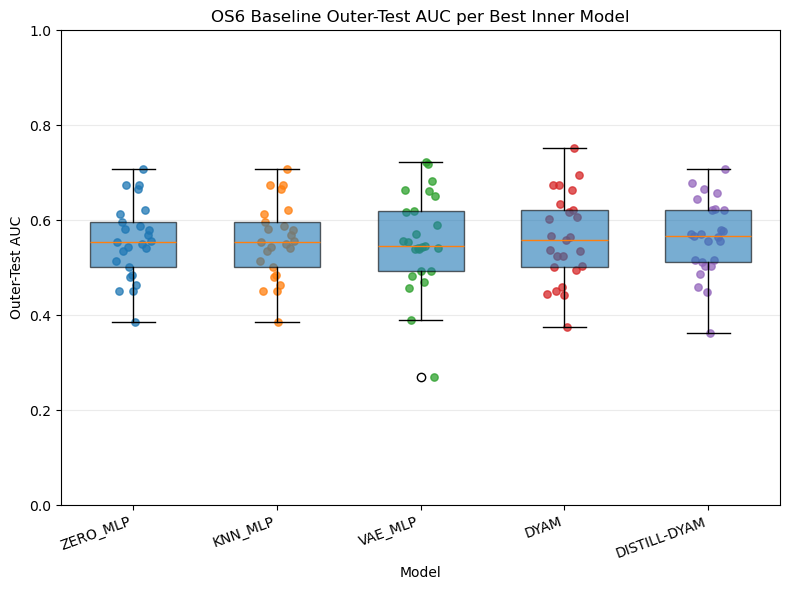

In [5]:
import matplotlib.pyplot as plt

BASELINE_MISSING_LOCATION = 'global'
BASELINE_TRAIN_MISSING_PROP = 0.0
BASELINE_TEST_MISSING_PROP = 0.0

baseline_rows = []
for model_name in MODEL_NAMES_TO_COMPARE:
    try:
        _, _, test_preds_df = load_run_tables(
            model_dir_name=model_name,
            dataset_name=DATASET_NAME,
            missing_location=BASELINE_MISSING_LOCATION,
            train_missing_prop=BASELINE_TRAIN_MISSING_PROP,
            seed=SEED,
        )
    except FileNotFoundError as exc:
        print(f'Skipping {model_name}: {exc}')
        continue

    auc_df = build_inner_model_auc_by_test_split_table(
        test_preds_df=test_preds_df,
        focus_test_missing_prop=BASELINE_TEST_MISSING_PROP,
    )
    auc_df = auc_df.copy()
    auc_df['model_name'] = model_name
    baseline_rows.append(auc_df)

if not baseline_rows:
    raise ValueError('No baseline inner-model AUC tables were found for the selected models.')

baseline_inner_auc_df = pd.concat(baseline_rows, ignore_index=True)
baseline_inner_auc_df = baseline_inner_auc_df.sort_values(
    ['model_name', 'outer_fold', 'inner_model_idx']
).reset_index(drop=True)

print('OS6 baseline setting: missing_location=global, train_missing_prop=0.0, test_missing_prop=0.0')
print(f'Total points: {len(baseline_inner_auc_df)}')
print()
print('=== OS6 baseline inner-model AUC table ===')
display(baseline_inner_auc_df)

plot_df = baseline_inner_auc_df[['model_name', 'auc']].copy()
model_order = [model_name for model_name in MODEL_NAMES_TO_COMPARE if model_name in plot_df['model_name'].unique()]
boxplot_data = [
    plot_df.loc[plot_df['model_name'] == model_name, 'auc'].to_numpy(dtype=float)
    for model_name in model_order
]

fig, ax = plt.subplots(figsize=(max(8, len(model_order) * 1.4), 6))
bp = ax.boxplot(boxplot_data, tick_labels=model_order, patch_artist=True, widths=0.6)
for patch in bp['boxes']:
    patch.set_alpha(0.6)

for x_pos, model_name in enumerate(model_order, start=1):
    y = plot_df.loc[plot_df['model_name'] == model_name, 'auc'].to_numpy(dtype=float)
    if len(y) == 0:
        continue
    jitter = np.linspace(-0.12, 0.12, num=len(y)) if len(y) > 1 else np.array([0.0])
    ax.scatter(np.full(len(y), x_pos) + jitter, y, alpha=0.75, s=28)

ax.set_title('OS6 Baseline Outer-Test AUC per Best Inner Model')
ax.set_xlabel('Model')
ax.set_ylabel('Outer-Test AUC')
ax.set_ylim(0.0, 1.0)
ax.grid(axis='y', alpha=0.25)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()

figures_dir = Path.cwd() / 'figures' if Path.cwd().name == 'analysis' else Path.cwd() / 'analysis' / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)
figure_path = figures_dir / 'baseline_boxplot_os6_HP_inner.png'
plt.savefig(figure_path, dpi=300, bbox_inches='tight')
print(f'Saved figure to: {figure_path}')
plt.show()
